# Project: Solar Energy Installation Analysis
Solar energy has become one of the fastest-growing renewable energy sources in Australia. Many households and businesses are installing solar panel systems to reduce electricity costs and lower carbon emissions. This project analyses solar installation and solar capacity trends across Australian states and territories between 2011 and 2025.

**Objectives**:

* Examine trends in solar installations over time,
* Compare solar adoption between states and territories,
* Identify growth patterns in renewable energy usage across Australia.
* 
**Workflow**: Load → Explore → Clean (filter data) → Aggregation (by region) → Visualization → Insights

**Data Sources and References**
This analysis uses sensitive internal datasets provided by Australian Renewable Energy Agency (ARENA).ARENA is interested in understanding  the factors influencing solar energy adopt on across different states and territories in Australia. All data and copyright being used belong to ARENA.

All data remains the property of ARENA and is restricted to analytical and reporting purposes within the organisation. 
The data set includes postcode-level solar installation records, state/territory identifiers, and population estimates. This datasets are also provided by the Australian Bureau of Statistics (ABS).

**Links**

* Both sgu-solar-capacity-2011-to-present-and-total and sgu-solar-installations-2011-to-present-and-total, Provided in starter pack for this assignment by NMTAFE.
* https://www.abs.gov.au/statistics/people/population/national-state-and-territory-population
* https://www.abs.gov.au/statistics/people/population/national-state-and-territory-population/sep-2025
* https://www.abs.gov.au/statistics/people/population/national-state-and-territory-population/latest-release



### Methodology

Python was used for the analysis with the following libraries:

* Pandas for data manipulation,
* NumPy for numerical operations,
* Matplotlib and Seaborn for data visualization.

The analysis involved:

1. loading the datasets,
2. cleaning and transforming the data,
3. grouping records by year and state,
4. visualizing solar trends across Australia.

In [2]:
# install packages for said project 
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install mathplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Step 1: Load the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
solar_capacity_df = pd.read_csv('sgu-solar-capacity-2011-to-present-and-totals.csv')
print(f"Loaded {len(solar_capacity_df):,} rows × {len(solar_capacity_df.columns)} columns")
solar_capacity_df.head()

Loaded 2,810 rows × 178 columns


,Small Unit Postcode,Historic Total Rated Power Output In kW (2001 - 2010),Jan 2011 - Rated Power Output In kW,Feb 2011 - Rated Power Output In kW,Mar 2011 - Rated Power Output In kW,Apr 2011 - Rated Power Output In kW,May 2011 - Rated Power Output In kW,Jun 2011 - Rated Power Output In kW,Jul 2011 - Rated Power Output In kW,Aug 2011 - Rated Power Output In kW,...,Nov 2024 - Rated Power Output In kW,Dec 2024 - Rated Power Output In kW,Jan 2025 - Rated Power Output In kW,Feb 2025 - Rated Power Output In kW,Mar 2025 - Rated Power Output In kW,Apr 2025 - Rated Power Output In kW,May 2025 - Rated Power Output In kW,Jun 2025 - Rated Power Output In kW,Jul 2025 - Rated Power Output In kW,Total Rated Power Output In kW
0,0,4.46,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,4.460
1,200,0.08,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.080
2,800,34.74,0.0,0.0,0.0,0.0,2.22,0.0,3.04,0.0,...,123.045,0.0,0.0,0.0,274.5,99.88,0.0,164.23,0.0,4928.175
3,801,3.44,0.0,0.0,0.0,0.0,2.02,0.0,0.00,0.0,...,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,386.598
4,803,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,11.685


## Dataset Description
Two datasets were used in this project:

1. **Solar Capacity Dataset**
* Measures solar power output in kilowatts (kW)
* Contains monthly data from 2011–2025
* Includes postcode-based records across Australia
2. **Solar Installation Dataset**
* Measures the number of solar installations
* Covers the same time period and postcode regions

In [2]:
solar_capacity_df.info()
solar_capacity_df.describe() 

<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Columns: 178 entries, Small Unit Postcode to Total Rated Power Output In kW
dtypes: float64(177), int64(1)
memory usage: 3.8 MB


,Small Unit Postcode,Historic Total Rated Power Output In kW (2001 - 2010),Jan 2011 - Rated Power Output In kW,Feb 2011 - Rated Power Output In kW,Mar 2011 - Rated Power Output In kW,Apr 2011 - Rated Power Output In kW,May 2011 - Rated Power Output In kW,Jun 2011 - Rated Power Output In kW,Jul 2011 - Rated Power Output In kW,Aug 2011 - Rated Power Output In kW,...,Nov 2024 - Rated Power Output In kW,Dec 2024 - Rated Power Output In kW,Jan 2025 - Rated Power Output In kW,Feb 2025 - Rated Power Output In kW,Mar 2025 - Rated Power Output In kW,Apr 2025 - Rated Power Output In kW,May 2025 - Rated Power Output In kW,Jun 2025 - Rated Power Output In kW,Jul 2025 - Rated Power Output In kW,Total Rated Power Output In kW
count,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,...,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000
mean,4168.266548,180.258767,20.679269,22.982555,28.511664,27.042775,41.266189,59.553616,19.254452,20.140893,...,96.599781,113.245737,63.394109,80.743511,83.354635,70.931454,70.325591,52.031738,42.526434,9575.233955
std,1592.968085,300.729756,42.076633,43.400588,51.380393,48.560529,75.581136,105.559607,37.929121,39.546335,...,171.460774,209.621779,124.060835,150.836322,149.111981,132.374325,132.808058,103.070242,84.652508,15602.295013
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.080000
25%,2845.250000,9.690000,0.000000,0.000000,0.000000,0.000000,0.000000,2.752500,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,769.946500
50%,3929.500000,61.752000,4.560000,6.110000,8.150000,7.512000,12.685000,19.337500,3.995000,4.940000,...,32.552500,37.840000,18.500000,25.960000,29.480000,22.575000,22.285000,13.200000,10.450000,3572.203500
75%,5340.750000,222.033500,23.756000,26.801250,34.588750,32.378750,47.706000,70.321250,20.558750,20.415000,...,122.855000,139.858750,75.732500,96.346250,105.112500,85.360000,83.186250,57.765000,48.681250,11895.593500
max,9729.000000,3164.003000,754.484000,572.100000,566.300000,470.395000,770.705000,1225.978000,355.611000,516.160000,...,2179.230000,3111.890000,1861.760000,1974.510000,2077.895000,1790.775000,1721.985000,1287.500000,960.645000,165866.824000


## Data Cleaning and Preparation
Several preprocessing steps were performed before analysis:

* Unnecessary historical columns from 2001–2010 were removed,
* Postcode columns were renamed for clarity,
* monthly columns were reshaped from wide format into long format,
* postcodes were matched to Australian states and territories,
* invalid postcode entries were removed,
* dates were converted into yearly values for trend analysis.

# Check for Missing Values

In [3]:
# Checking for missing values 
missing_values_count = solar_capacity_df.isnull().sum()

# checking for percentage missing 
total_cells = solar_capacity_df.size  # rows x columns 
total_missing = missing_values_count.sum() 
percent_missing = (total_missing) * 100 
print(percent_missing)


0


# State / Territory 

In [16]:
import pandas as pd 

postcode_table = pd.DataFrame({
    "State/Territory": ["NSW", "ACT", "VIC", "QLD", "SA", "WA", "TAS", "NT"],
    "Postcode Range": [
        "2000-2599",
        "2600-2999", 
        "3000-3999",
        "4000-4999", 
        "5000-5999", 
        "6000-6999",
        "7000-7999",
        "0800-0999", 
    ]
})
postcode_table

,State/Territory,Postcode Range
0,NSW,2000-2599
1,ACT,2600-2999
2,VIC,3000-3999
3,QLD,4000-4999
4,SA,5000-5999
5,WA,6000-6999
6,TAS,7000-7999
7,NT,0800-0999


In [17]:
# Split the range into numberic start/end using postcode table 
postcode_table[["start", "end"]] = (
    postcode_table["Postcode Range"].str.split("-", expand=True).astype(int)
)

# Save table as a csv file 
postcode_table.to_csv("postcode_mapping.csv", index=False)
postcode_table.head() 

,State/Territory,Postcode Range,start,end
0,NSW,2000-2599,2000,2599
1,ACT,2600-2999,2600,2999
2,VIC,3000-3999,3000,3999
3,QLD,4000-4999,4000,4999
4,SA,5000-5999,5000,5999


In [18]:
# Save table as a csv file 
postcode_table.to_csv("postcode_mapping.csv", index=False)

## Clean Columns for Solar Capacity (2011-2025)  

In [216]:
# Strip column name for Dates strip from ( - Rated Power Output in kW) 
solar_capacity_df.columns = (solar_capacity_df.columns.str.split("-").str[0])

# Rename first column to Postcode
solar_capacity_df = solar_capacity_df.rename(columns={"Small Unit Postcode": "Postcode"})

# Remove not used columns
# Historic Total Rated Power Output In kW (2001 - 2010)
solar_capacity_df = solar_capacity_df.drop(
    columns=[col for col in solar_capacity_df.columns if "2001" in col]
) 

# Reshape the data format from wide -> long 
solar_long = solar_capacity_df.melt(
    id_vars=["Postcode"], 
    var_name="date",
    value_name="capacity" )

print(solar_long.head(10))


   Postcode       date capacity
0         0  Jan 2011       0.0
1       200  Jan 2011       0.0
2       800  Jan 2011       0.0
3       801  Jan 2011       0.0
4       803  Jan 2011       0.0
5       804  Jan 2011       0.0
6       810  Jan 2011      3.02
7       811  Jan 2011       0.0
8       812  Jan 2011       3.0
9       813  Jan 2011       0.0


## Merge Solar Capacity Data with their respective State/Territory Postcode 
Combine solar capacity data trends with postcode-based State/Territory 

In [217]:
# Check which Postcode it falls into 

def get_state(pc):
    row = postcode_table[(pc >= postcode_table["start"]) & (pc <= postcode_table["end"])]
    if not row.empty:
        return row["State/Territory"].iloc[0]
    return None 

In [218]:
# Apply function to Solar Capacity dataframe 
solar_capacity_df["State/Territory"] = (
    solar_capacity_df["Postcode"].astype(int).apply(get_state)
)
solar_capacity_df.head()

# Reshape the data format from wide -> long 
solar_long = solar_capacity_df.melt(
    id_vars=["Postcode", "State/Territory"], 
    var_name="date",
    value_name="capacity" )

print(solar_long.head())

   Postcode State/Territory       date  capacity
0         0             NaN  Jan 2011        0.0
1       200             NaN  Jan 2011        0.0
2       800              NT  Jan 2011        0.0
3       801              NT  Jan 2011        0.0
4       803              NT  Jan 2011        0.0


In [181]:
# Drop Nan values for State/Territory -> drop postcode 0, 200 
solar_long = solar_long.dropna(subset=["State/Territory"])
solar_long.head() 

,Postcode,State/Territory,date,capacity
2,800,NT,Jan 2011,0.00
3,801,NT,Jan 2011,0.00
4,803,NT,Jan 2011,0.00
5,804,NT,Jan 2011,0.00
6,810,NT,Jan 2011,3.02


# Format Dates from Column to year

In [220]:
# Convert date to real datetime objects 
solar_long["date"] = pd.to_datetime(solar_long["date"], errors="coerce")
solar_long["date"].isna().sum()

C:\Users\kabyw\AppData\Local\Temp\ipykernel_38488\858281054.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  solar_long["date"] = pd.to_datetime(solar_long["date"], errors="coerce")


np.int64(2810)

In [221]:
# Extract yearly data 
solar_long["year"] = solar_long["date"].dt.year

# Aggregate to yearly
solar_yearly = solar_long.groupby("year")["capacity"].sum().reset_index() 
solar_yearly.head()

# Check to handle zero in dataset 
# (solar_long["capacity"] == 0).mean() * 100   # gives np.float64(32.04565674538984)
# solar_yearly = solar_yearly[solar_yearly["capacity"] > 0]
# print(solar_yearly)

,year,capacity
0,2011.0,872239.836
1,2012.0,1035750.287
2,2013.0,792188.984
3,2014.0,800261.301
4,2015.0,705967.095


# Solar Capacity Trends by State/Territory

In [253]:
solar_long["State/Territory"]
solar_long.columns

Index(['Postcode', 'State/Territory', 'date', 'capacity', 'year', 'Year'], dtype='str')

In [185]:
solar_by_state = solar_long.groupby("State/Territory")["capacity"].sum().reset_index()


# Solar Capacity per State/Territory per year 

In [222]:
solar_long["Year"] = solar_long["date"].dt.year

# Aggregate 
solar_by_state_year = (
    solar_long.groupby(["State/Territory", "Year"])["capacity"].sum().reset_index()
)
solar_by_state_year

,State/Territory,Year,capacity
0,ACT,2011.0,67875.753
1,ACT,2012.0,41189.284
2,ACT,2013.0,52857.500
3,ACT,2014.0,52175.184
4,ACT,2015.0,58740.550
...,...,...,...
115,WA,2021.0,353317.798
116,WA,2022.0,286828.657
117,WA,2023.0,273494.216
118,WA,2024.0,285067.544


# Solar Installation Data Trends


In [187]:
# Load CSV
solar_installation_df = pd.read_csv('sgu-solar-installations-2011-to-present-and-totals.csv')
print(f"Loaded {len(solar_installation_df ):,} rows × {len(solar_installation_df .columns)} columns")
solar_installation_df.head()

Loaded 2,810 rows × 178 columns


,Small Unit Installation Postcode,Historic Total Installation Quantity (2001 - 2010),Jan 2011 - Installation Quantity,Feb 2011 - Installation Quantity,Mar 2011 - Installation Quantity,Apr 2011 - Installation Quantity,May 2011 - Installation Quantity,Jun 2011 - Installation Quantity,Jul 2011 - Installation Quantity,Aug 2011 - Installation Quantity,...,Nov 2024 - Installation Quantity,Dec 2024 - Installation Quantity,Jan 2025 - Installation Quantity,Feb 2025 - Installation Quantity,Mar 2025 - Installation Quantity,Apr 2025 - Installation Quantity,May 2025 - Installation Quantity,Jun 2025 - Installation Quantity,Jul 2025 - Installation Quantity,Total Installation Quantity
0,0,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
1,200,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,800,7,0,0,0,0,1,0,1,0,...,2,0,0,0,3,1,0,2,0,147
3,801,2,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,12
4,803,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [188]:
solar_installation_df.info()
solar_installation_df.describe() 

<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Columns: 178 entries, Small Unit Installation Postcode to Total Installation Quantity
dtypes: int64(178)
memory usage: 3.8 MB


,Small Unit Installation Postcode,Historic Total Installation Quantity (2001 - 2010),Jan 2011 - Installation Quantity,Feb 2011 - Installation Quantity,Mar 2011 - Installation Quantity,Apr 2011 - Installation Quantity,May 2011 - Installation Quantity,Jun 2011 - Installation Quantity,Jul 2011 - Installation Quantity,Aug 2011 - Installation Quantity,...,Nov 2024 - Installation Quantity,Dec 2024 - Installation Quantity,Jan 2025 - Installation Quantity,Feb 2025 - Installation Quantity,Mar 2025 - Installation Quantity,Apr 2025 - Installation Quantity,May 2025 - Installation Quantity,Jun 2025 - Installation Quantity,Jul 2025 - Installation Quantity,Total Installation Quantity
count,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,...,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000
mean,4168.266548,100.822420,9.062633,10.266904,12.643416,11.807473,17.896441,24.507829,7.907473,7.874377,...,9.459431,9.884698,6.762989,8.264057,8.216726,7.175445,7.114235,5.438790,4.364413,1485.610676
std,1592.968085,173.362941,19.484976,20.600454,24.161736,22.295651,34.868082,44.076386,16.140359,15.743275,...,17.113820,18.781449,13.517234,15.683298,15.280305,13.759886,14.048666,11.169237,8.858543,2484.238328
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2845.250000,4.250000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,104.250000
50%,3929.500000,32.000000,2.000000,2.500000,3.000000,3.000000,5.000000,7.000000,2.000000,2.000000,...,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,1.000000,1.000000,522.500000
75%,5340.750000,123.000000,10.000000,12.000000,14.750000,13.000000,19.000000,28.000000,8.000000,8.000000,...,12.000000,12.000000,8.000000,10.000000,10.000000,8.000000,8.000000,6.000000,5.000000,1836.750000
max,9729.000000,2035.000000,442.000000,309.000000,273.000000,244.000000,451.000000,462.000000,156.000000,207.000000,...,199.000000,313.000000,225.000000,218.000000,226.000000,214.000000,227.000000,160.000000,112.000000,24716.000000


In [189]:
# Checking for missing values 
missing_values_count = solar_installation_df.isnull().sum()

# checking for percentage missing 
total_cells = solar_installation_df.size  # rows x columns 
total_missing = missing_values_count.sum() 
percent_missing = (total_missing) * 100 
print(percent_missing)

0


## Format Data for Solar Installation (2011-2025) 

In [192]:
# Strip column name for Dates strip from ( - Rated Power Output in kW) 
solar_installation_df.columns = (solar_installation_df.columns.str.split("-").str[0])

# Rename first column to Postcode
solar_installation_df = solar_installation_df.rename(columns={"Small Unit Installation Postcode": "Postcode"})

# Remove not used columns
# Historic Total Rated Power Output In kW (2001 - 2010)
solar_installation_df = solar_installation_df.drop(
    columns=[col for col in solar_installation_df.columns if "2001" in col]
) 

# Reshape the data format from wide -> long 
solar_installation_long = solar_installation_df.melt(
    id_vars=["Postcode"], 
    var_name="date",
    value_name="quantity" )

print(solar_installation_long.head(10))

   Postcode       date quantity
0         0  Jan 2011         0
1       200  Jan 2011         0
2       800  Jan 2011         0
3       801  Jan 2011         0
4       803  Jan 2011         0
5       804  Jan 2011         0
6       810  Jan 2011         2
7       811  Jan 2011         0
8       812  Jan 2011         1
9       813  Jan 2011         0


## Merge Solar Installation Data with their respective State/Territory Postcode 
Combine solar installation data trends with postcode-based State/Territory 

In [194]:
# Apply function to Solar Installation dataframe 
solar_installation_df["State/Territory"] = (
    solar_installation_df["Postcode"].astype(int).apply(get_state)
)
solar_installation_df.head()

# Reshape the data format from wide -> long 
solar_installation_long = solar_installation_df.melt(
    id_vars=["Postcode", "State/Territory"], 
    var_name="date",
    value_name="quantity" )

print(solar_installation_long.head())


   Postcode State/Territory       date  quantity
0         0             NaN  Jan 2011          0
1       200             NaN  Jan 2011          0
2       800              NT  Jan 2011          0
3       801              NT  Jan 2011          0
4       803              NT  Jan 2011          0


In [195]:
# Drop Nan values for State/Territory -> drop postcode 0, 200 
solar_installation_long = solar_installation_long.dropna(subset=["State/Territory"])
solar_installation_long.head() 

,Postcode,State/Territory,date,quantity
2,800,NT,Jan 2011,0
3,801,NT,Jan 2011,0
4,803,NT,Jan 2011,0
5,804,NT,Jan 2011,0
6,810,NT,Jan 2011,2


### Clean Dates Column to year

In [196]:
# Convert date to real datetime objects 
solar_installation_long["date"] = pd.to_datetime(solar_installation_long["date"], errors="coerce")
solar_installation_long["date"].isna().sum()

# Extract yearly data 
solar_installation_long["year"] = solar_installation_long["date"].dt.year

# Aggregate to yearly
solar_yearly = solar_installation_long.groupby("year")["quantity"].sum().reset_index() 
solar_yearly.head(25)

C:\Users\kabyw\AppData\Local\Temp\ipykernel_38488\1796411224.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  solar_installation_long["date"] = pd.to_datetime(solar_installation_long["date"], errors="coerce")


,year,quantity
0,2011.0,360730
1,2012.0,343302
2,2013.0,200406
3,2014.0,180136
4,2015.0,141494
5,2016.0,132692
6,2017.0,174939
7,2018.0,224842
8,2019.0,284028
9,2020.0,370315


## Solar Installation Trends by State/Territory 

In [197]:
solar_installation_long["State/Territory"]
solar_installation_long.columns

Index(['Postcode', 'State/Territory', 'date', 'quantity', 'year'], dtype='str')

In [198]:
solar_installation_by_state = solar_installation_long.groupby("State/Territory")["quantity"].sum().reset_index()

## Solar Installation per State/Territory per Year 
This data shows how solar installation numbers have evolved around states from 2011 to 2025. 

In [199]:
solar_installation_long["Year"] = solar_long["date"].dt.year

# Aggregate 
solar_installation_by_state_year = (
    solar_installation_long.groupby(["State/Territory", "Year"])["quantity"].sum().reset_index()
)
solar_installation_by_state_year

,State/Territory,Year,quantity
0,ACT,2011.0,24774
1,ACT,2012.0,13426
2,ACT,2013.0,12556
3,ACT,2014.0,10783
4,ACT,2015.0,10277
...,...,...,...
115,WA,2021.0,48780
116,WA,2022.0,38691
117,WA,2023.0,35213
118,WA,2024.0,35535


# Australia's Populations table from ABS - All states  

In [14]:
%pip install openpyxl 


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [73]:
population_data = pd.DataFrame(pd.read_excel("Australia_population.xlsx"))
population_data.head()

,Unnamed: 0,Estimated Resident Population ; Male ; New South Wales ;,Estimated Resident Population ; Male ; Victoria ;,Estimated Resident Population ; Male ; Queensland ;,Estimated Resident Population ; Male ; South Australia ;,Estimated Resident Population ; Male ; Western Australia ;,Estimated Resident Population ; Male ; Tasmania ;,Estimated Resident Population ; Male ; Northern Territory ;,Estimated Resident Population ; Male ; Australian Capital Territory ;,Estimated Resident Population ; Male ; Australia ;,...,Estimated Resident Population ; Female ; Australia ;,Estimated Resident Population ; Persons ; New South Wales ;,Estimated Resident Population ; Persons ; Victoria ;,Estimated Resident Population ; Persons ; Queensland ;,Estimated Resident Population ; Persons ; South Australia ;,Estimated Resident Population ; Persons ; Western Australia ;,Estimated Resident Population ; Persons ; Tasmania ;,Estimated Resident Population ; Persons ; Northern Territory ;,Estimated Resident Population ; Persons ; Australian Capital Territory ;,Estimated Resident Population ; Persons ; Australia ;
0,Unit,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,...,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons
1,Series Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,...,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original
2,Data Type,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,...,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE,STOCK_CLOSE
3,Frequency,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,...,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter,Quarter
4,Collection Month,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3


In [74]:
# check dataset 
population_data.info() 
population_data.describe() 

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 28 columns):
 #   Column                                                                      Non-Null Count  Dtype 
---  ------                                                                      --------------  ----- 
 0   Unnamed: 0                                                                  187 non-null    object
 1   Estimated Resident Population ;  Male ;  New South Wales ;                  187 non-null    object
 2   Estimated Resident Population ;  Male ;  Victoria ;                         187 non-null    object
 3   Estimated Resident Population ;  Male ;  Queensland ;                       187 non-null    object
 4   Estimated Resident Population ;  Male ;  South Australia ;                  187 non-null    object
 5   Estimated Resident Population ;  Male ;  Western Australia ;                187 non-null    object
 6   Estimated Resident Population ;  Male ;  Tasmania ;                  

,Unnamed: 0,Estimated Resident Population ; Male ; New South Wales ;,Estimated Resident Population ; Male ; Victoria ;,Estimated Resident Population ; Male ; Queensland ;,Estimated Resident Population ; Male ; South Australia ;,Estimated Resident Population ; Male ; Western Australia ;,Estimated Resident Population ; Male ; Tasmania ;,Estimated Resident Population ; Male ; Northern Territory ;,Estimated Resident Population ; Male ; Australian Capital Territory ;,Estimated Resident Population ; Male ; Australia ;,...,Estimated Resident Population ; Female ; Australia ;,Estimated Resident Population ; Persons ; New South Wales ;,Estimated Resident Population ; Persons ; Victoria ;,Estimated Resident Population ; Persons ; Queensland ;,Estimated Resident Population ; Persons ; South Australia ;,Estimated Resident Population ; Persons ; Western Australia ;,Estimated Resident Population ; Persons ; Tasmania ;,Estimated Resident Population ; Persons ; Northern Territory ;,Estimated Resident Population ; Persons ; Australian Capital Territory ;,Estimated Resident Population ; Persons ; Australia ;
count,187,187,187,187,187,187,187,187,187,187,...,187,187,187,187,187,187,187,187,187,187
unique,187,187,187,187,187,187,187,187,187,187,...,187,187,187,187,187,187,186,187,187,187
top,Unit,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,Persons,...,Persons,Persons,Persons,Persons,Persons,Persons,473430,Persons,Persons,Persons
freq,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,2,1,1,1


# Remove Unwanted data from Columns  

In [110]:
# Clean data and drop metadata 
population_data["Date"] = pd.to_datetime(
    population_data["Unnamed: 0"], 
    format="%b-%Y",
    errors="coerce"
)
population_data = population_data.dropna(subset=["Date"])
# population_data

In [113]:
# filter year from 2011-2025
population_data = population_data[
    (population_data["Date"].dt.year >= 2011) &
    (population_data["Date"].dt.year <= 2025)
]

# keep 6 months rows so June
population_yearly = population_data[population_data["Date"].dt.month == 6]

# Extract only "Persons" columns 
persons_cols = [col for col in population_yearly.columns if col.startswith("Persons")]
population_persons = population_yearly[persons_cols].copy()
population_persons

,Persons ; New South Wales ;,Persons ; Victoria ;,Persons ; Queensland ;,Persons ; South Australia ;,Persons ; Western Australia ;,Persons ; Tasmania ;,Persons ; Northern Territory ;,Persons ; Australian Capital Territory ;,Persons ; Australia ;
129,7218529,5537817,4476778,1639614,2353409,511483,231292,367985,22340024
133,7304244,5651091,4568687,1656725,2425507,511724,235915,376539,22733465
137,7404032,5772669,4652824,1671488,2486944,512231,241722,383257,23128129
141,7508353,5894917,4719653,1686945,2517608,513621,242894,388799,23475686
145,7616168,6022322,4777692,1700668,2540672,515117,244692,395813,23815995
149,7732858,6173172,4845152,1712843,2555978,517514,245678,403104,24190907
153,7855316,6302608,4926380,1728673,2585720,526762,247412,415046,24592588
157,7954476,6423038,5006623,1746137,2617792,537291,247095,426081,24963258
161,8046748,6537305,5088847,1767395,2659625,547841,246559,435730,25334826
165,8110610,6615046,5165613,1790355,2712912,557578,247428,444903,25649248


In [137]:
# Subset the DataFrame to only "Persons" column
cleaned_cols = {} 
for col in persons_cols:
    parts = col.split(";") # split column name 
    parts = [p.strip() for p in parts if p.strip()] # remove empty spaces 
    state_name = parts[-1]  # last part is state/territory 
    cleaned_cols[col] = state_name # original -> cleaned 

# rename the column 
population_persons = population_persons.rename(columns=cleaned_cols)

# population_persons

# Merge clean Population Dataset 


In [138]:
# Add Year column 
population_yearly["Year"] = population_yearly["Date"].dt.year
population_persons["Year"] = population_yearly["Year"].values

population_merged = population_yearly[["Date", "Year"]].merge(
    population_persons,
    on="Year",
    how="left"
)
population_merged

,Date,Year,New South Wales,Victoria,Queensland,South Australia,Western Australia,Tasmania,Northern Territory,Australian Capital Territory,Australia
0,2011-06-01,2011,7218529,5537817,4476778,1639614,2353409,511483,231292,367985,22340024
1,2012-06-01,2012,7304244,5651091,4568687,1656725,2425507,511724,235915,376539,22733465
2,2013-06-01,2013,7404032,5772669,4652824,1671488,2486944,512231,241722,383257,23128129
3,2014-06-01,2014,7508353,5894917,4719653,1686945,2517608,513621,242894,388799,23475686
4,2015-06-01,2015,7616168,6022322,4777692,1700668,2540672,515117,244692,395813,23815995
5,2016-06-01,2016,7732858,6173172,4845152,1712843,2555978,517514,245678,403104,24190907
6,2017-06-01,2017,7855316,6302608,4926380,1728673,2585720,526762,247412,415046,24592588
7,2018-06-01,2018,7954476,6423038,5006623,1746137,2617792,537291,247095,426081,24963258
8,2019-06-01,2019,8046748,6537305,5088847,1767395,2659625,547841,246559,435730,25334826
9,2020-06-01,2020,8110610,6615046,5165613,1790355,2712912,557578,247428,444903,25649248


# Merge solar_by_state_year with population_merged 

In [232]:
state_map = {
    "NSW": "New South Wales",
    "VIC": "Victoria",
    "QLD": "Queensland",
    "SA": "South Australia",
    "WA": "Western Australia",
    "TAS": "Tasmania",
    "NT": "Northern Territory",
    "ACT": "Australian Capital Territory"
}

In [233]:
solar_by_state_year["State_Full"] = solar_by_state_year["State/Territory"].map(state_map)

# Solar Capacity per Year with Population and State 

To better understand solar energy adoption across Australia, solar capacity data was combined with state population estimates. This allowed the analysis to compare total installed solar capacity relative to population size rather than relying only on raw totals. 

The population dataset was first transformed into long format to align with the yearly solar capacity records. The datasets were then merged using: 
* Year
* State/Territory
* Full state name
  
This produced a combined dataset containing
* solar capacity,
* annual population estimates

In [234]:
# convert to long format 
population_capacity_long = population_merged.melt(
    id_vars=["Year", "Date"],
    var_name="State_Full",
    value_name="Population"
)

In [235]:
population_capacity_long["State_Full"].unique()
population_capacity_long

,Year,Date,State_Full,Population
0,2011,2011-06-01,New South Wales,7218529
1,2012,2012-06-01,New South Wales,7304244
2,2013,2013-06-01,New South Wales,7404032
3,2014,2014-06-01,New South Wales,7508353
4,2015,2015-06-01,New South Wales,7616168
...,...,...,...,...
130,2021,2021-06-01,Australia,25685412
131,2022,2022-06-01,Australia,26018721
132,2023,2023-06-01,Australia,26659922
133,2024,2024-06-01,Australia,27194286


In [236]:
# merge solar capacity + population 
solar_with_capacity_population = solar_by_state_year.merge(
    population_capacity_long[["Year", "State_Full", "Population"]],
    on=["Year", "State_Full"],
    how="left"
)
solar_with_capacity_population

,State/Territory,Year,capacity,State_Full,Population
0,ACT,2011.0,67875.753,Australian Capital Territory,367985
1,ACT,2012.0,41189.284,Australian Capital Territory,376539
2,ACT,2013.0,52857.500,Australian Capital Territory,383257
3,ACT,2014.0,52175.184,Australian Capital Territory,388799
4,ACT,2015.0,58740.550,Australian Capital Territory,395813
...,...,...,...,...,...
115,WA,2021.0,353317.798,Western Australia,2749365
116,WA,2022.0,286828.657,Western Australia,2793934
117,WA,2023.0,273494.216,Western Australia,2890936
118,WA,2024.0,285067.544,Western Australia,2978147


In [ ]:
import matplotlib.pyplot as plt

# Pick a year to visualize
year_to_plot = 2020

# Filter the dataset
subset = solar_combined[solar_combined["Year"] == year_to_plot]

# Sort for nicer plotting
subset = subset.sort_values("capacity", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(subset["State_Full"], subset["capacity"], color="steelblue")

plt.title(f"Total Solar Capacity by State in {year_to_plot}")
plt.xlabel("State/Territory")
plt.ylabel("Installed Capacity (kW)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Solar Installation per Year with Population and State 

In [237]:
solar_installation_by_state_year["State_Full"] = solar_by_state_year["State/Territory"].map(state_map)

In [238]:
# convert to long format 
population_installation_long = population_merged.melt(
    id_vars=["Year", "Date"],
    var_name="State_Full",
    value_name="Population"
)

population_installation_long["State_Full"].unique()
population_installation_long

,Year,Date,State_Full,Population
0,2011,2011-06-01,New South Wales,7218529
1,2012,2012-06-01,New South Wales,7304244
2,2013,2013-06-01,New South Wales,7404032
3,2014,2014-06-01,New South Wales,7508353
4,2015,2015-06-01,New South Wales,7616168
...,...,...,...,...
130,2021,2021-06-01,Australia,25685412
131,2022,2022-06-01,Australia,26018721
132,2023,2023-06-01,Australia,26659922
133,2024,2024-06-01,Australia,27194286


In [239]:
# merge solar installation + population 
solar_with_quantity_population = solar_installation_by_state_year.merge(
    population_installation_long[["Year", "State_Full", "Population"]],
    on=["Year", "State_Full"],
    how="left"
)
solar_with_quantity_population

,State/Territory,Year,quantity,State_Full,Population
0,ACT,2011.0,24774,Australian Capital Territory,367985
1,ACT,2012.0,13426,Australian Capital Territory,376539
2,ACT,2013.0,12556,Australian Capital Territory,383257
3,ACT,2014.0,10783,Australian Capital Territory,388799
4,ACT,2015.0,10277,Australian Capital Territory,395813
...,...,...,...,...,...
115,WA,2021.0,48780,Western Australia,2749365
116,WA,2022.0,38691,Western Australia,2793934
117,WA,2023.0,35213,Western Australia,2890936
118,WA,2024.0,35535,Western Australia,2978147


In [240]:
# Merge Solar capacity + solar installation + population / year Data 
solar_installation_df.columns 

Index(['Postcode', 'Jan 2011 ', 'Feb 2011 ', 'Mar 2011 ', 'Apr 2011 ',
       'May 2011 ', 'Jun 2011 ', 'Jul 2011 ', 'Aug 2011 ', 'Sep 2011 ',
       ...
       'Dec 2024 ', 'Jan 2025 ', 'Feb 2025 ', 'Mar 2025 ', 'Apr 2025 ',
       'May 2025 ', 'Jun 2025 ', 'Jul 2025 ', 'Total Installation Quantity',
       'State/Territory'],
      dtype='str', length=178)

In [242]:
# merge capacity + installation 
solar_combined = solar_with_capacity_population.merge(
    solar_with_quantity_population[["State_Full", "Year", "quantity"]],
    on=["State_Full", "Year"],
    how="outer" )

solar_combined

,State/Territory,Year,capacity,State_Full,Population,quantity
0,ACT,2011.0,67875.753,Australian Capital Territory,367985,24774
1,ACT,2012.0,41189.284,Australian Capital Territory,376539,13426
2,ACT,2013.0,52857.500,Australian Capital Territory,383257,12556
3,ACT,2014.0,52175.184,Australian Capital Territory,388799,10783
4,ACT,2015.0,58740.550,Australian Capital Territory,395813,10277
...,...,...,...,...,...,...
115,WA,2021.0,353317.798,Western Australia,2749365,48780
116,WA,2022.0,286828.657,Western Australia,2793934,38691
117,WA,2023.0,273494.216,Western Australia,2890936,35213
118,WA,2024.0,285067.544,Western Australia,2978147,35535


### Solar Capacity by State (Bar Chart)
This bar chart shows the total installed solar capacity (measured in kilowatts) for each Australian state and territory in a selected year. 

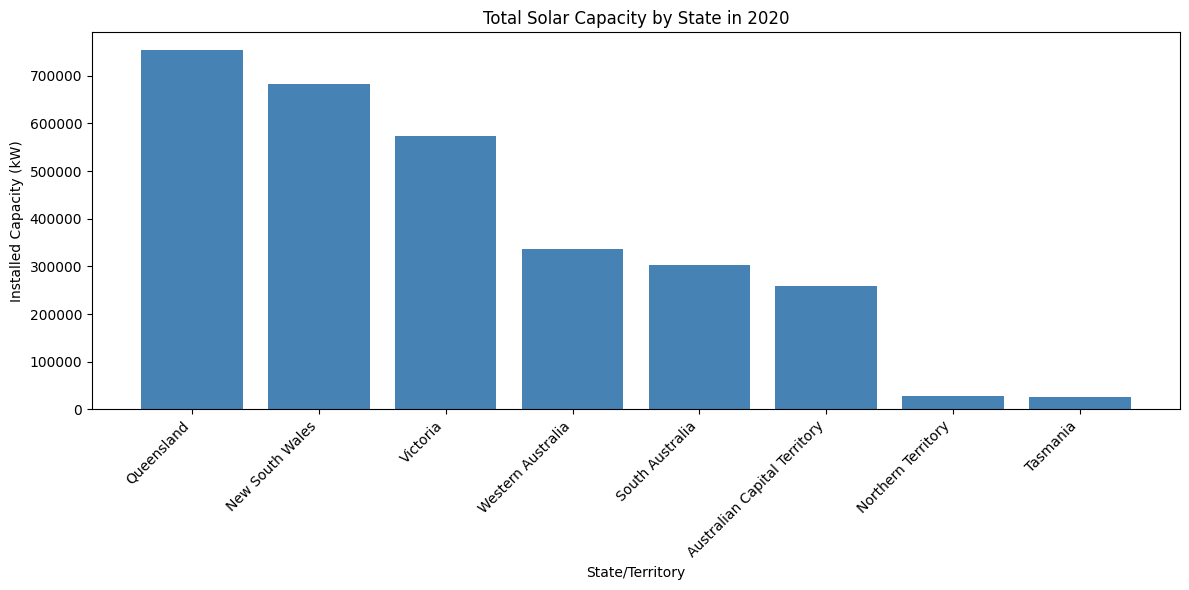

In [251]:
import matplotlib.pyplot as plt

# Pick a year to visualize
year_to_plot = 2020

# Filter the dataset
subset = solar_combined[solar_combined["Year"] == year_to_plot]

# Sort for nicer plotting
subset = subset.sort_values("capacity", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(subset["State_Full"], subset["capacity"], color="steelblue")

plt.title(f"Total Solar Capacity by State in {year_to_plot}")
plt.xlabel("State/Territory")
plt.ylabel("Installed Capacity (kW)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Key Findings
**Larger States Recorded the Highest Total Capacity**

The chart shows that:
* New South Wales,
* Queensland,
* Victoria,

recorded the highest levels of installed solar capacity in 2020. These states have the largest populations in Australia, which contributes to their high total solar output.

**Queensland Demonstrated Strong Solar Adoption**

Queensland recorded particularly strong solar capacity levels, reflecting the state’s favourable climate conditions and high levels of household solar participation. 

**Smaller Territories Recorded Lower Totals**

The Australian Capital Territory and Northern Territory showed lower total installed capacity compared to larger states. This is largely due to their smaller populations and fewer residential areas.

**National Growth in Renewable Energy**

The overall distribution of solar capacity across states indicates that renewable energy adoption had become widespread by 2020. Nearly every state demonstrated substantial installed capacity, highlighting Australia’s increasing reliance on solar energy technologies.

### Solar Installations by State (Bar Chart)
This bar chart displays the number of solar system installations recorded in each Australian state and territory for a selected year.  

In [1]:
import matplotlib.pyplot as plt

year_to_plot = 2020

subset = solar_combined[solar_combined["Year"] == year_to_plot]
subset = subset.sort_values("quantity", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(subset["State_Full"], subset["quantity"], color="orange")

plt.title(f"Solar Installations (Quantity) by State in {year_to_plot}")
plt.xlabel("State/Territory")
plt.ylabel("Number of Installations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

NameError: name 'solar_combined' is not defined

### Key Findings
**Queensland and New South Wales Led Installation Activity**

Queensland and New South Wales recorded the highest numbers of solar installations during 2020. This suggests strong household participation in renewable energy adoption and increasing demand for residential solar systems.

**Installation Growth Reflects Rising Demand for Renewable Energy**

The high installation numbers observed across multiple states indicate that solar energy adoption accelerated significantly during this period. Several factors may have contributed to this growth, including:

* increasing electricity prices,
* government rebates and incentives,
* improved affordability of solar technology,
* growing public awareness of environmental sustainability.

**Smaller Regions Had Lower Installation Numbers**
States and territories with smaller populations, such as Tasmania and the Northern Territory, recorded lower installation totals. However, lower totals do not necessarily indicate weaker adoption rates, as population size strongly affects raw installation counts.


# Australia's Solar Capacity, Installations and Population by State (2011-2025) 

This dataset combines three key sources of information to provide a comprehensive view of solar energy adoption across Australian states and territories from 2011 to 2025:

- **Solar Capacity (kW):** Total installed solar capacity recorded each year.
- **Solar Installations (Quantity):** Number of new solar systems installed annually.
- **Population:** State-level population estimates used to standardize solar metrics.

To enable fair comparison across states with different population sizes, the dataset includes population‑standardized indicators:

- **Capacity per Person:** Installed solar capacity divided by population.
- **Installations per Person:** Number of installations divided by population.
- **Capacity per 100,000 People:** A normalized metric commonly used in energy and public reporting.
- **Installations per 100,000 People:** Standardized installation rate.
 
These metrics allow for meaningful cross‑state comparisons and trend analysis, highlighting how solar adoption has evolved relative to population growth.


In [244]:
solar_final = solar_combined[
    ["State_Full", "State/Territory", "Year",
     "capacity", "quantity", "Population"]
]

solar_final["capacity_per_person"] = (
    solar_final["capacity"] / solar_final["Population"]
)

solar_final["installs_per_person"] = (
    solar_final["quantity"] / solar_final["Population"]
)

solar_final["capacity_per_100k"] = solar_final["capacity_per_person"] * 100000
solar_final["installs_per_100k"] = solar_final["installs_per_person"] * 100000

solar_final

,State_Full,State/Territory,Year,capacity,quantity,Population,capacity_per_person,installs_per_person,capacity_per_100k,installs_per_100k
0,Australian Capital Territory,ACT,2011.0,67875.753,24774,367985,0.184452,0.067323,18445.249942,6732.339633
1,Australian Capital Territory,ACT,2012.0,41189.284,13426,376539,0.109389,0.035656,10938.915756,3565.633308
2,Australian Capital Territory,ACT,2013.0,52857.500,12556,383257,0.137917,0.032761,13791.659383,3276.130638
3,Australian Capital Territory,ACT,2014.0,52175.184,10783,388799,0.134196,0.027734,13419.577725,2773.412483
4,Australian Capital Territory,ACT,2015.0,58740.550,10277,395813,0.148405,0.025964,14840.480227,2596.428111
...,...,...,...,...,...,...,...,...,...,...
115,Western Australia,WA,2021.0,353317.798,48780,2749365,0.128509,0.017742,12850.887314,1774.227867
116,Western Australia,WA,2022.0,286828.657,38691,2793934,0.102661,0.013848,10266.121426,1384.821546
117,Western Australia,WA,2023.0,273494.216,35213,2890936,0.094604,0.01218,9460.403689,1218.048411
118,Western Australia,WA,2024.0,285067.544,35535,2978147,0.09572,0.011932,9571.976937,1193.191605


# Visual Graph - Solar Capacity per 100k People 

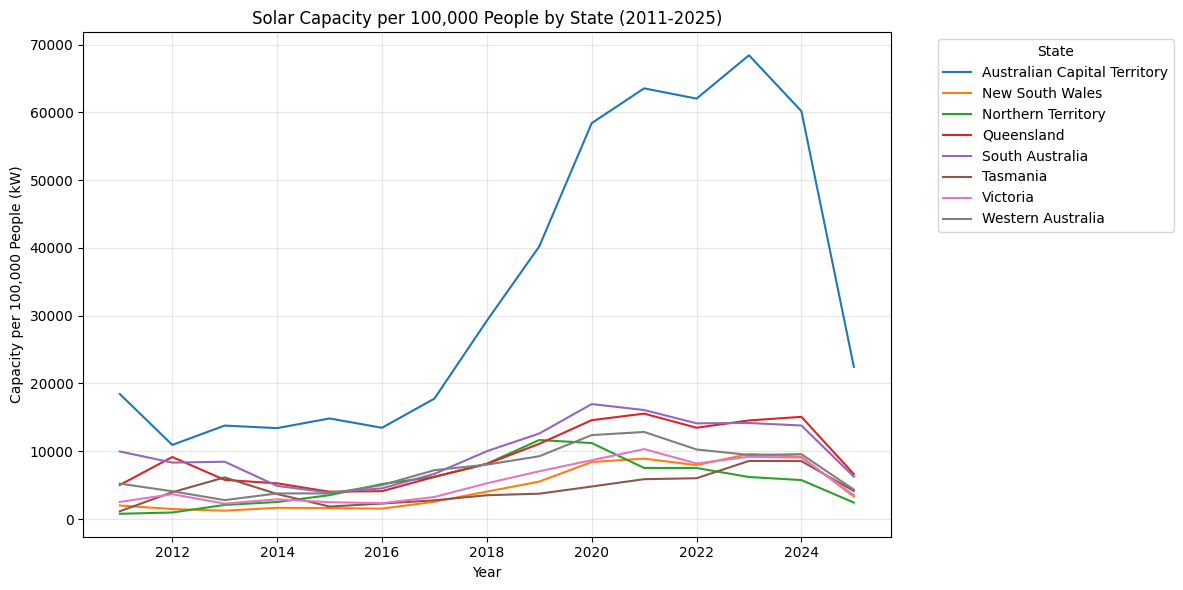

In [248]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(12, 6))

for state in solar_final["State_Full"].unique():
    subset = solar_final[solar_final["State_Full"] == state]
    plt.plot(subset["Year"], subset["capacity_per_100k"], label=state)

plt.title("Solar Capacity per 100,000 People by State (2011-2025)")
plt.xlabel("Year")
plt.ylabel("Capacity per 100,000 People (kW)")
plt.legend(title="State",bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Insights: Solar Capacity per 100,000 People
**South Australia** leads in capacity per 100k people, reflecting its long‑standing policy support and high household solar capacity.

**New South Wales and Victoria**, despite having the largest populations, show lower per‑capita capacity, suggesting that high population dilutes their totals when standardised.

**Australian Capital Territory** displays the largest peaks and drops in per‑100k metrics due to its small population, which amplifies even modest changes in solar installations and capacity

# Visual Graph - Installations per 100k People 

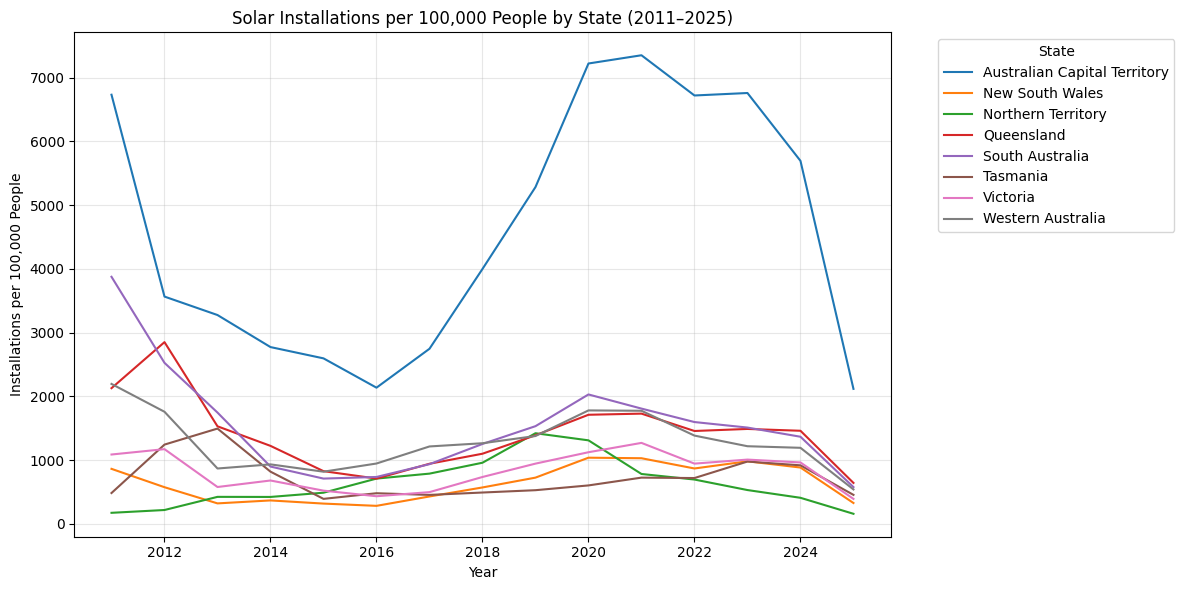

In [254]:
plt.figure(figsize=(12, 6))

for state in solar_final["State_Full"].unique():
    subset = solar_final[solar_final["State_Full"] == state]
    plt.plot(subset["Year"], subset["installs_per_100k"], label=state)

plt.title("Solar Installations per 100,000 People by State (2011–2025)")
plt.xlabel("Year")
plt.ylabel("Installations per 100,000 People")
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Insights: Solar Installations per 100,000 People (2011–2025) 
**The ACT** shows the most dramatic peaks and drops across the entire period.
Because the ACT has a small population, even modest changes in installation numbers translate into very large per‑100k values. 

**Queensland and South Australia** consistently show high installation rates, reflecting strong household uptake, favourable solar conditions.

#### Conclusion

This analysis examined solar capacity, installation activity, and population trends across Australian states and territories from 2011 to 2025.

The results indicate that:

* Solar adoption has increased substantially over time,
* South Australia achieved the strongest per-capita solar performance,
* Queensland maintained consistently high installation rates,
* Population-standardised metrics provide clearer comparisons between states.

Overall, the study highlights the continued expansion of solar energy adoption across Australia and demonstrates the importance of using per-capita measures when comparing regions with different population sizes.